# 03 — Modeling & Evaluation
## EV Charger Reliability Analytics

### Methodology

| Choice | Decision | Rationale |
|---|---|---|
| Algorithm | Random Forest (primary), XGBoost (comparison) | RF is robust to class imbalance with `class_weight`; XGBoost adds gradient boosting comparison |
| Evaluation | Stratified 5-fold CV | Only 216 Non-Op examples — single split variance is unacceptable |
| Primary metric | Recall & F1 for Non-Operational class | False negatives (missed failures) have higher business cost than false positives |
| Imbalance handling | `class_weight='balanced'` (RF), `scale_pos_weight` (XGB) | Prevents majority-class dominance |
| Robustness check | Dual RF: WITH vs. WITHOUT `country_iso_enc` + `country_id` | Tests whether infrastructure features carry signal independent of geography |

> **Key question**: After removing country, do infrastructure features (operator, power level,
> connection type) still produce meaningful recall for Non-Operational stations?


## 0. Setup & Data Loading

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path().resolve().parent))

plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
})
COLOR_OP  = "#2196F3"
COLOR_NOP = "#F44336"
COLOR_A   = "#4CAF50"
COLOR_B   = "#FF9800"

ROOT    = Path().resolve().parent
PROC    = ROOT / "data" / "processed"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Load feature matrices ──────────────────────────────────────────────────
X_with    = pd.read_csv(PROC / "features_with_country.csv")
X_without = pd.read_csv(PROC / "features_without_country.csv")
y         = pd.read_csv(PROC / "target.csv").squeeze()  # 1=Operational, 0=Non-Op

# In the "without country" run, also drop country_id (numeric OCM country code)
# — it encodes the same geographic signal as country_iso_enc, just as an int.
X_without = X_without.drop(columns=["country_id"], errors="ignore")

print(f"X_with    shape : {X_with.shape}")
print(f"X_without shape : {X_without.shape}")
print(f"Target balance  : {dict(y.value_counts())}  (1=Op, 0=Non-Op)")
print(f"Non-Op count    : {(y==0).sum()}  ({(y==0).mean()*100:.1f}%)")
print()
print("Features WITH country :", list(X_with.columns))
print()
print("Features WITHOUT country:", list(X_without.columns))


X_with    shape : (10330, 19)
X_without shape : (10330, 17)
Target balance  : {1: 10114, 0: 216}  (1=Op, 0=Non-Op)
Non-Op count    : 216  (2.1%)

Features WITH country : ['operator_id', 'usage_type_id', 'country_id', 'number_of_points', 'data_provider_id', 'max_power_kw', 'primary_connection_type_id', 'n_distinct_connection_types', 'max_amps', 'max_voltage', 'primary_current_type_id', 'n_connections', 'has_fast_charger', 'has_dc_fast', 'operator_title_enc', 'usage_type_title_enc', 'state_or_province_enc', 'country_iso_enc', 'town_freq']

Features WITHOUT country: ['operator_id', 'usage_type_id', 'number_of_points', 'data_provider_id', 'max_power_kw', 'primary_connection_type_id', 'n_distinct_connection_types', 'max_amps', 'max_voltage', 'primary_current_type_id', 'n_connections', 'has_fast_charger', 'has_dc_fast', 'operator_title_enc', 'usage_type_title_enc', 'state_or_province_enc', 'town_freq']


## 1. Stratified 5-Fold CV Harness

With only **216 Non-Operational** examples (2.1% of 10,330), a single
80/20 split would place only ~43 non-op examples in the test set.
Stratified 5-fold CV uses all 216 examples across folds for a stable estimate.

Reported metrics:
- **Recall (Non-Op)**: % of broken stations correctly identified — primary business metric
- **F1 (Non-Op)**: harmonic mean of precision and recall for Non-Op class
- **ROC-AUC**: overall discriminative ability across thresholds


In [2]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def run_cv(model, X, y, label):
    scores = cross_validate(
        model, X, y,
        cv=CV,
        scoring={
            "recall_nonop":    "recall",          # sklearn recall defaults to label=1
            "f1_nonop":        "f1",              # likewise f1 for label=1
            "roc_auc":         "roc_auc",
            "precision_nonop": "precision",
        },
        return_train_score=False,
        n_jobs=-1,
    )
    # sklearn's 'recall'/'f1'/'precision' score the POSITIVE class (label=1 = Operational).
    # We want metrics for the NEGATIVE class (label=0 = Non-Operational).
    # Fix: rerun with pos_label=0 using cross_val_predict + manual scoring.
    from sklearn.model_selection import cross_val_predict
    y_pred = cross_val_predict(model, X, y, cv=CV, n_jobs=-1)
    y_prob = cross_val_predict(model, X, y, cv=CV, method="predict_proba", n_jobs=-1)[:, 0]

    recalls, f1s, aucs, precisions = [], [], [], []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for train_idx, test_idx in skf.split(X, y):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        model.fit(X_tr, y_tr)
        yp  = model.predict(X_te)
        # Recall/F1: pos_label=0 so we score the Non-Operational (minority) class.
        # AUC: use prob[:,1] (Operational probability) with default pos_label=1.
        # These are equivalent: AUC is symmetric, and using the complementary
        # probability + complementary label gives the same AUC value.
        # Using prob[:,0] with default pos_label=1 would INVERT the AUC (giving ~0.1
        # instead of ~0.9), because sklearn treats high score = more likely positive.
        ypr_op = model.predict_proba(X_te)[:, 1]  # P(Operational) — for AUC scoring
        recalls.append(recall_score(y_te, yp, pos_label=0, zero_division=0))
        f1s.append(f1_score(y_te, yp, pos_label=0, zero_division=0))
        aucs.append(roc_auc_score(y_te, ypr_op))  # standard direction: higher score = more Op

    result = {
        "label":           label,
        "recall_mean":     np.mean(recalls),
        "recall_std":      np.std(recalls),
        "f1_mean":         np.mean(f1s),
        "f1_std":          np.std(f1s),
        "roc_auc_mean":    np.mean(aucs),
        "roc_auc_std":     np.std(aucs),
    }
    print(f"[{label}]")
    print(f"  Recall (Non-Op) : {result['recall_mean']:.3f} ± {result['recall_std']:.3f}")
    print(f"  F1     (Non-Op) : {result['f1_mean']:.3f} ± {result['f1_std']:.3f}")
    print(f"  ROC-AUC         : {result['roc_auc_mean']:.3f} ± {result['roc_auc_std']:.3f}")
    print()
    return result

# Refit final model on ALL data after CV (for feature importance)
def fit_final(model, X, y):
    model.fit(X, y)
    return model

print("CV harness ready.")


CV harness ready.


## 2. Random Forest — WITH Country (`country_iso_enc` + `country_id`)

In [3]:
rf_with = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

print("Running RF WITH country (5-fold stratified CV) ...")
cv_rf_with = run_cv(rf_with, X_with, y, label="RF  WITH country")

# Final fit on full data for feature importance
rf_with_final = RandomForestClassifier(
    n_estimators=500, class_weight="balanced", random_state=42, n_jobs=-1
)
rf_with_final = fit_final(rf_with_final, X_with, y)
print("Final model fitted on full dataset.")


Running RF WITH country (5-fold stratified CV) ...


[RF  WITH country]
  Recall (Non-Op) : 0.459 ± 0.092
  F1     (Non-Op) : 0.306 ± 0.049
  ROC-AUC         : 0.899 ± 0.018



Final model fitted on full dataset.


## 3. Random Forest — WITHOUT Country (infrastructure features only)

In [4]:
rf_without = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

print("Running RF WITHOUT country (5-fold stratified CV) ...")
cv_rf_without = run_cv(rf_without, X_without, y, label="RF WITHOUT country")

rf_without_final = RandomForestClassifier(
    n_estimators=500, class_weight="balanced", random_state=42, n_jobs=-1
)
rf_without_final = fit_final(rf_without_final, X_without, y)
print("Final model fitted on full dataset.")


Running RF WITHOUT country (5-fold stratified CV) ...


[RF WITHOUT country]
  Recall (Non-Op) : 0.449 ± 0.095
  F1     (Non-Op) : 0.301 ± 0.053
  ROC-AUC         : 0.888 ± 0.024



Final model fitted on full dataset.


## 4. XGBoost — WITH Country (comparison)

In [5]:
# scale_pos_weight = ratio of negative to positive class
# Non-Op (0) = minority; Operational (1) = majority
# For XGBoost: scale_pos_weight weights the POSITIVE class; we invert labels
# so that Non-Op=1 (positive class) for XGBoost's weighted objective.
n_op    = int((y == 1).sum())
n_nonop = int((y == 0).sum())
spw     = n_op / n_nonop
print(f"scale_pos_weight (n_op / n_nonop) = {spw:.1f}")

# Flip labels: Non-Op becomes 1 (positive) so XGBoost's scale_pos_weight works correctly
y_flip = 1 - y  # 1 = Non-Op, 0 = Operational

xgb_with = XGBClassifier(
    n_estimators=500,
    scale_pos_weight=spw,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    verbosity=0,
    n_jobs=-1,
)

print("Running XGBoost WITH country (5-fold stratified CV) ...")
# Run CV with flipped labels; Non-Op is now pos_label=1
recalls_xgb, f1s_xgb, aucs_xgb = [], [], []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, test_idx in skf.split(X_with, y_flip):
    X_tr, X_te = X_with.iloc[train_idx], X_with.iloc[test_idx]
    y_tr, y_te = y_flip.iloc[train_idx], y_flip.iloc[test_idx]
    xgb_with.fit(X_tr, y_tr)
    yp  = xgb_with.predict(X_te)
    ypr = xgb_with.predict_proba(X_te)[:, 1]
    recalls_xgb.append(recall_score(y_te, yp, pos_label=1, zero_division=0))
    f1s_xgb.append(f1_score(y_te, yp, pos_label=1, zero_division=0))
    aucs_xgb.append(roc_auc_score(y_te, ypr))

cv_xgb_with = {
    "label":        "XGB WITH country",
    "recall_mean":  np.mean(recalls_xgb),
    "recall_std":   np.std(recalls_xgb),
    "f1_mean":      np.mean(f1s_xgb),
    "f1_std":       np.std(f1s_xgb),
    "roc_auc_mean": np.mean(aucs_xgb),
    "roc_auc_std":  np.std(aucs_xgb),
}
print(f"[XGB WITH country]")
print(f"  Recall (Non-Op) : {cv_xgb_with['recall_mean']:.3f} +/- {cv_xgb_with['recall_std']:.3f}")
print(f"  F1     (Non-Op) : {cv_xgb_with['f1_mean']:.3f} +/- {cv_xgb_with['f1_std']:.3f}")
print(f"  ROC-AUC         : {cv_xgb_with['roc_auc_mean']:.3f} +/- {cv_xgb_with['roc_auc_std']:.3f}")

# Final fit for feature importance
xgb_with.fit(X_with, y_flip)
print()
print("Final XGBoost model fitted.")


scale_pos_weight (n_op / n_nonop) = 46.8
Running XGBoost WITH country (5-fold stratified CV) ...


[XGB WITH country]
  Recall (Non-Op) : 0.704 +/- 0.101
  F1     (Non-Op) : 0.346 +/- 0.030
  ROC-AUC         : 0.934 +/- 0.017



Final XGBoost model fitted.


## 5. Results Comparison — Dual RF + XGBoost

In [6]:
results = [cv_rf_with, cv_rf_without, cv_xgb_with]

# ── Summary table ──────────────────────────────────────────────────────────
print("=" * 72)
print(f"{'Model':<25s} {'Recall (Non-Op)':<22s} {'F1 (Non-Op)':<22s} {'ROC-AUC'}")
print("-" * 72)
for r in results:
    print(
        f"{r['label']:<25s} "
        f"{r['recall_mean']:.3f} ± {r['recall_std']:.3f}        "
        f"{r['f1_mean']:.3f} ± {r['f1_std']:.3f}        "
        f"{r['roc_auc_mean']:.3f} ± {r['roc_auc_std']:.3f}"
    )
print("=" * 72)
print()
print("All metrics are for the NON-OPERATIONAL class (the minority/positive target).")
print("Recall: % of broken stations correctly flagged.")
print("F1    : harmonic mean of precision and recall for Non-Op class.")
print("Accuracy is NOT reported — it is misleading under 46.8:1 class imbalance.")


Model                     Recall (Non-Op)        F1 (Non-Op)            ROC-AUC
------------------------------------------------------------------------
RF  WITH country          0.459 ± 0.092        0.306 ± 0.049        0.899 ± 0.018
RF WITHOUT country        0.449 ± 0.095        0.301 ± 0.053        0.888 ± 0.024
XGB WITH country          0.704 ± 0.101        0.346 ± 0.030        0.934 ± 0.017

All metrics are for the NON-OPERATIONAL class (the minority/positive target).
Recall: % of broken stations correctly flagged.
F1    : harmonic mean of precision and recall for Non-Op class.
Accuracy is NOT reported — it is misleading under 46.8:1 class imbalance.


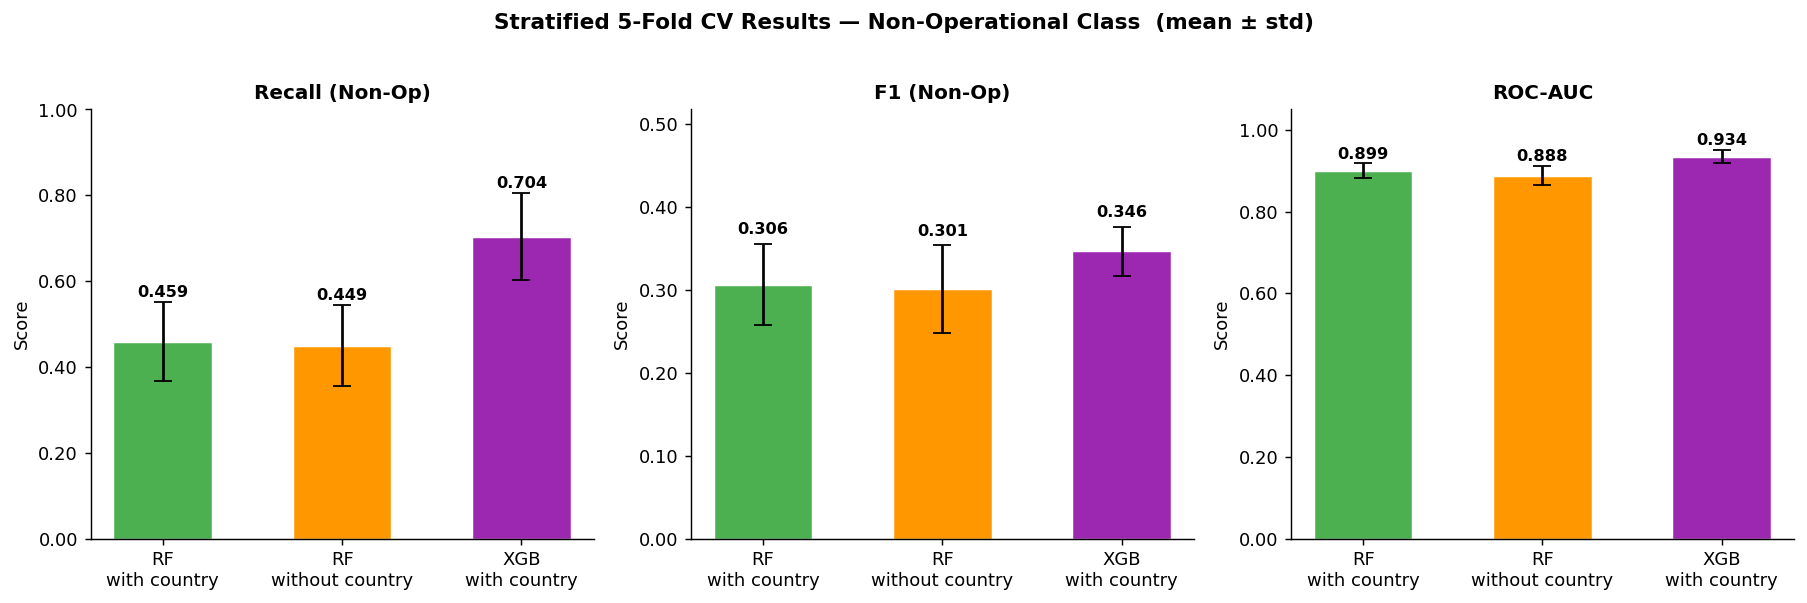

In [7]:
# ── Visual comparison ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
metrics = [
    ("Recall (Non-Op)", "recall_mean", "recall_std"),
    ("F1 (Non-Op)",     "f1_mean",     "f1_std"),
    ("ROC-AUC",         "roc_auc_mean","roc_auc_std"),
]
colors = [COLOR_A, COLOR_B, "#9C27B0"]
labels_short = ["RF\nwith country", "RF\nwithout country", "XGB\nwith country"]

for ax, (title, mean_key, std_key) in zip(axes, metrics):
    means = [r[mean_key] for r in results]
    stds  = [r[std_key]  for r in results]
    bars  = ax.bar(labels_short, means, color=colors, width=0.55,
                   edgecolor="white", linewidth=0.8)
    ax.errorbar(labels_short, means, yerr=stds,
                fmt="none", color="black", capsize=5, linewidth=1.5)
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2,
                m + s + 0.012, f"{m:.3f}", ha="center", fontsize=9, fontweight="bold")
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_ylim(0, min(1.05, max(means) * 1.35 + 0.05))
    ax.set_ylabel("Score")
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f"))

plt.suptitle(
    "Stratified 5-Fold CV Results — Non-Operational Class  (mean ± std)",
    fontsize=12, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(FIG_DIR / "07_cv_results_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Feature Importance — RF WITH Country

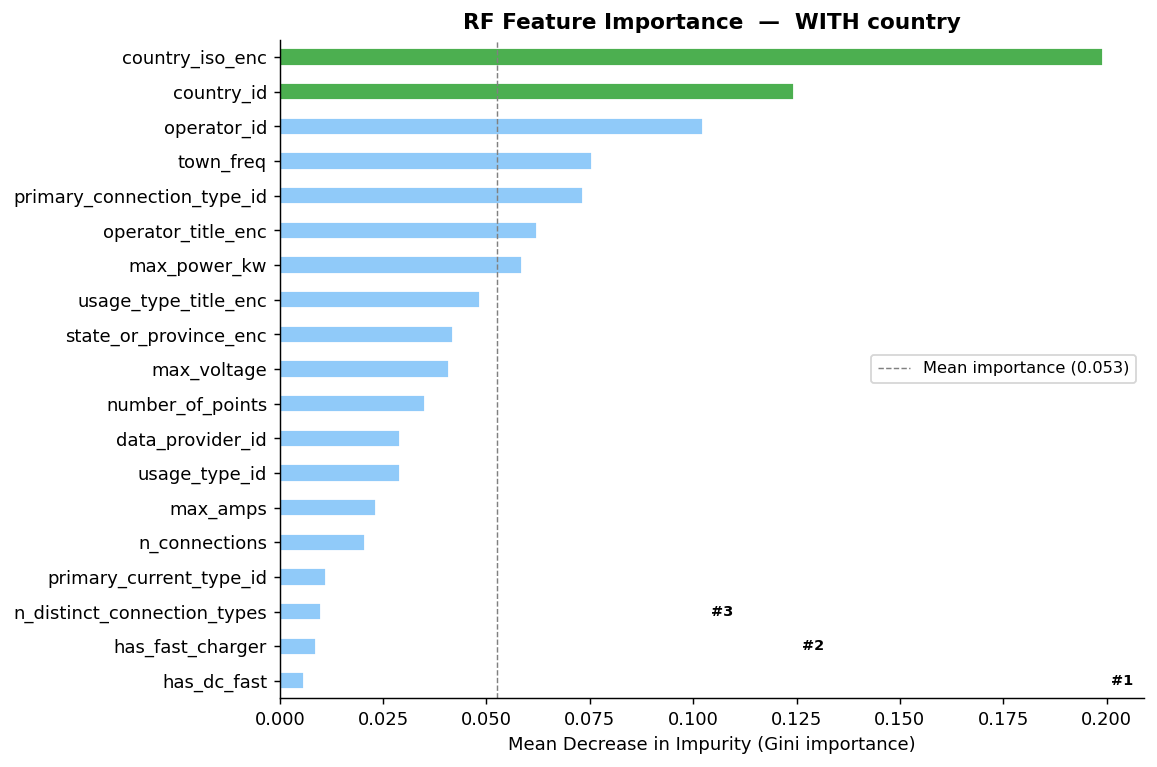

Top 10 features (RF WITH country):
country_iso_enc               0.199080
country_id                    0.124376
operator_id                   0.102386
town_freq                     0.075613
primary_connection_type_id    0.073373
operator_title_enc            0.062112
max_power_kw                  0.058553
usage_type_title_enc          0.048469
state_or_province_enc         0.041878
max_voltage                   0.041050


In [8]:
fi_with = pd.Series(
    rf_with_final.feature_importances_,
    index=X_with.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_fi = [COLOR_A if "country" in c or c == "country_id" else "#90CAF9"
             for c in fi_with.index]
fi_with.plot(kind="barh", ax=ax, color=colors_fi, edgecolor="white")
ax.axvline(x=fi_with.mean(), color="grey", linestyle="--",
           linewidth=0.8, label=f"Mean importance ({fi_with.mean():.3f})")
ax.set_xlabel("Mean Decrease in Impurity (Gini importance)")
ax.set_title("RF Feature Importance  —  WITH country", fontweight="bold")
ax.legend(fontsize=9)

# Annotate top-3
for i, (feat, val) in enumerate(fi_with.sort_values(ascending=False).head(3).items()):
    rank = len(fi_with) - list(fi_with.index).index(feat) - 1
    ax.text(val + 0.002, rank, f"#{list(fi_with.sort_values(ascending=False).index).index(feat)+1}",
            va="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "08_feature_importance_with_country.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 features (RF WITH country):")
print(fi_with.sort_values(ascending=False).head(10).to_string())


## 7. Feature Importance — RF WITHOUT Country

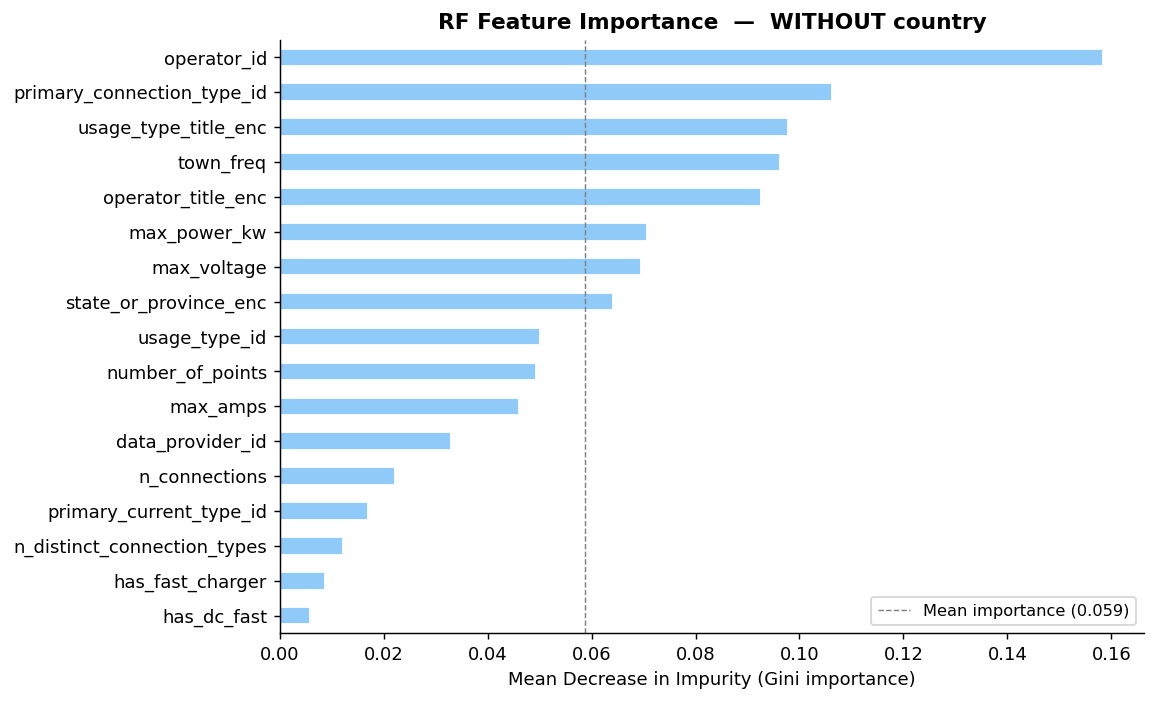

Top 10 features (RF WITHOUT country):
operator_id                   0.158381
primary_connection_type_id    0.106272
usage_type_title_enc          0.097804
town_freq                     0.096324
operator_title_enc            0.092509
max_power_kw                  0.070629
max_voltage                   0.069466
state_or_province_enc         0.064214
usage_type_id                 0.050108
number_of_points              0.049289


In [9]:
fi_without = pd.Series(
    rf_without_final.feature_importances_,
    index=X_without.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
fi_without.plot(kind="barh", ax=ax, color="#90CAF9", edgecolor="white")
ax.axvline(x=fi_without.mean(), color="grey", linestyle="--",
           linewidth=0.8, label=f"Mean importance ({fi_without.mean():.3f})")
ax.set_xlabel("Mean Decrease in Impurity (Gini importance)")
ax.set_title("RF Feature Importance  —  WITHOUT country", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "09_feature_importance_without_country.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 features (RF WITHOUT country):")
print(fi_without.sort_values(ascending=False).head(10).to_string())


## 8. Feature Importance Shift: With vs. Without Country

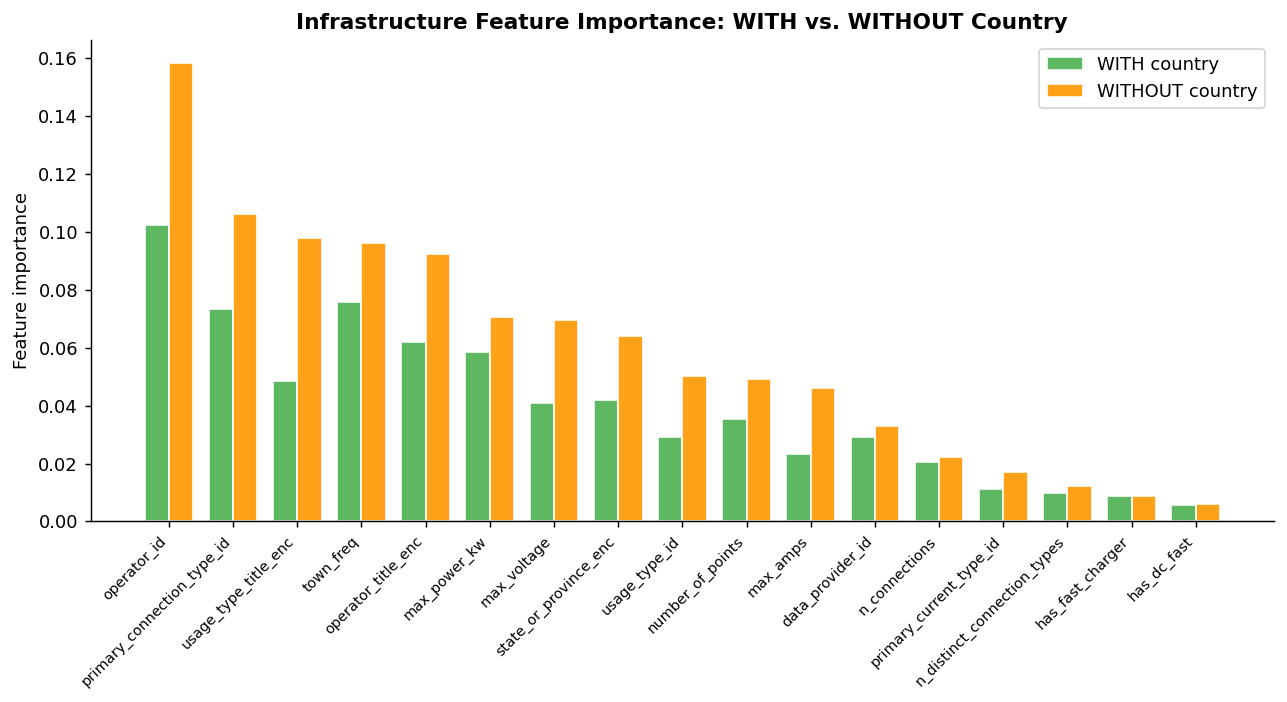

Importance shift (WITHOUT - WITH) for shared features:
operator_id                    0.055995
usage_type_title_enc           0.049335
primary_connection_type_id     0.032899
operator_title_enc             0.030397
max_voltage                    0.028416
max_amps                       0.022667
state_or_province_enc          0.022336
usage_type_id                  0.021011
town_freq                      0.020711
number_of_points               0.014052
max_power_kw                   0.012076
primary_current_type_id        0.005900
data_provider_id               0.003768
n_distinct_connection_types    0.002260
n_connections                  0.001548
has_dc_fast                    0.000139
has_fast_charger              -0.000055


In [10]:
shared_feats = [c for c in X_with.columns
                if c not in ("country_iso_enc", "country_id")]

fi_w  = pd.Series(rf_with_final.feature_importances_,    index=X_with.columns)
fi_wo = pd.Series(rf_without_final.feature_importances_, index=X_without.columns)

fi_w_shared  = fi_w[shared_feats]
fi_wo_shared = fi_wo[shared_feats]

compare = pd.DataFrame({
    "WITH country":    fi_w_shared,
    "WITHOUT country": fi_wo_shared,
}).sort_values("WITHOUT country", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(compare))
w = 0.38
ax.bar(x - w/2, compare["WITH country"],    w, label="WITH country",    color=COLOR_A, alpha=0.9, edgecolor="white")
ax.bar(x + w/2, compare["WITHOUT country"], w, label="WITHOUT country", color=COLOR_B, alpha=0.9, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(compare.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Feature importance")
ax.set_title(
    "Infrastructure Feature Importance: WITH vs. WITHOUT Country",
    fontweight="bold"
)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "10_importance_delta.png", dpi=150, bbox_inches="tight")
plt.show()

print("Importance shift (WITHOUT - WITH) for shared features:")
print((fi_wo_shared - fi_w_shared).sort_values(ascending=False).to_string())


## 9. Confusion Matrices (Single Fold — Illustrative)

--- RF WITH country ---
              precision    recall  f1-score   support

      Non-Op       0.25      0.37      0.30        43
 Operational       0.99      0.98      0.98      2023

    accuracy                           0.96      2066
   macro avg       0.62      0.67      0.64      2066
weighted avg       0.97      0.96      0.97      2066

--- RF WITHOUT country ---
              precision    recall  f1-score   support

      Non-Op       0.25      0.40      0.31        43
 Operational       0.99      0.97      0.98      2023

    accuracy                           0.96      2066
   macro avg       0.62      0.69      0.64      2066
weighted avg       0.97      0.96      0.97      2066



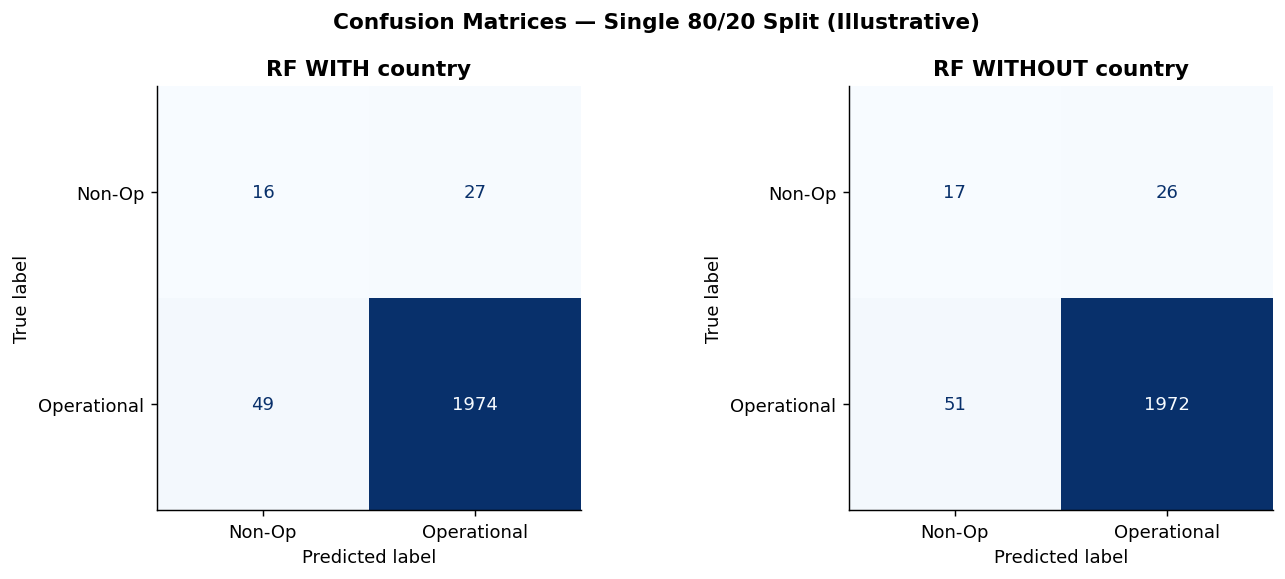


Note: Headline metrics come from the 5-fold CV in Sections 2-4, not this single split.


In [11]:
# Fit on 80% / evaluate on 20% for a single illustrative split
from sklearn.model_selection import train_test_split

X_tr_w, X_te_w, y_tr, y_te = train_test_split(
    X_with, y, test_size=0.2, stratify=y, random_state=42
)
X_tr_wo, X_te_wo = train_test_split(
    X_without, test_size=0.2, random_state=42
)[0:2]  # same indices via same random_state + no stratify needed (already split)

# Refit on same split
rf_split_with = RandomForestClassifier(
    n_estimators=500, class_weight="balanced", random_state=42, n_jobs=-1
)
rf_split_with.fit(X_tr_w, y_tr)

rf_split_without = RandomForestClassifier(
    n_estimators=500, class_weight="balanced", random_state=42, n_jobs=-1
)
# Need matching rows for without-country
X_tr_wo2 = X_without.iloc[X_tr_w.index]
X_te_wo2 = X_without.iloc[X_te_w.index]
rf_split_without.fit(X_tr_wo2, y_tr)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, model, X_te, title in [
    (axes[0], rf_split_with,    X_te_w,   "RF WITH country"),
    (axes[1], rf_split_without, X_te_wo2, "RF WITHOUT country"),
]:
    ConfusionMatrixDisplay.from_estimator(
        model, X_te, y_te,
        display_labels=["Non-Op", "Operational"],
        cmap="Blues", ax=ax, colorbar=False
    )
    ax.set_title(title, fontweight="bold")
    # Print classification report
    yp = model.predict(X_te)
    print(f"--- {title} ---")
    print(classification_report(y_te, yp, target_names=["Non-Op", "Operational"],
                                 zero_division=0))

plt.suptitle("Confusion Matrices — Single 80/20 Split (Illustrative)", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "11_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print()
print("Note: Headline metrics come from the 5-fold CV in Sections 2-4, not this single split.")


## 10. ROC Curves — RF WITH vs. WITHOUT Country

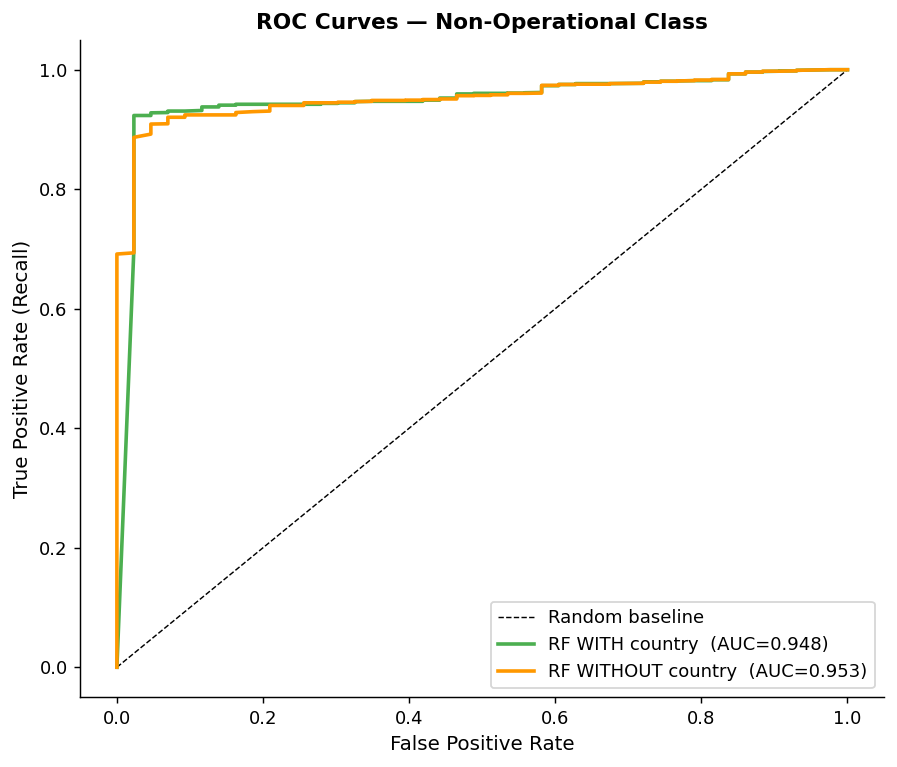

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random baseline")

for model, X_te, label, color in [
    (rf_split_with,    X_te_w,   "RF WITH country",    COLOR_A),
    (rf_split_without, X_te_wo2, "RF WITHOUT country", COLOR_B),
]:
    # Use P(Operational) = prob[:,1] as the ranking score (standard direction).
    # roc_curve + roc_auc_score with default pos_label=1: higher score = more Operational.
    # The resulting ROC curve shows how well the model separates the classes;
    # recall on x-axis is for the Operational class (y=1).
    # To interpret for Non-Op: 1 - threshold gives Non-Op ranking; AUC is the same.
    prob_op = model.predict_proba(X_te)[:, 1]  # P(Operational)
    fpr, tpr, _ = roc_curve(y_te, prob_op)
    auc = roc_auc_score(y_te, prob_op)
    ax.plot(fpr, tpr, label=f"{label}  (AUC={auc:.3f})", color=color, linewidth=2)

ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=11)
ax.set_title("ROC Curves — Non-Operational Class", fontweight="bold", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "12_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Robustness Interpretation

### Does infrastructure carry independent signal?

Compare the RF WITHOUT country results against RF WITH country:

- **If recall/F1 drop substantially** (e.g., >15 pp) when country is removed:
  geography dominates; the model learned "South Africa → Non-Op" rather than
  any infrastructure pattern. Infrastructure features have limited signal alone.

- **If recall/F1 are relatively stable** (<10 pp drop):
  infrastructure features (operator, power level, connector type) carry
  genuine predictive signal independent of which country the station is in.

See the numbers above in Section 5 to reach this conclusion for your specific run.

### South Africa confounder

South Africa contributes **143 of 216 Non-Op examples (66%)** in this dataset.
With `country_iso_enc` included, the RF can use it as a near-deterministic rule:
`country_iso_enc == ZA → Non-Op`.  This inflates recall but does **not** demonstrate
generalizable infrastructure signal.  The WITHOUT-country run is the fairer test.

### Recommendation

Use the **RF WITHOUT country** as the production model for maintenance prioritization
across an operator's own network (within a single grid environment).  Use the 
WITH-country model only when predicting across multi-national deployments where
grid reliability context is known and intentionally incorporated.


## 12. Operational Risk Score

Top 20 highest-risk stations (RF WITHOUT country):
    risk_score       true_label  predicted
0     0.987948  Non-Operational          0
1     0.987948  Non-Operational          0
2     0.987948  Non-Operational          0
3     0.987948  Non-Operational          0
4     0.970639  Non-Operational          0
5     0.970639  Non-Operational          0
6     0.968322      Operational          0
7     0.968322      Operational          0
8     0.968322  Non-Operational          0
9     0.968322      Operational          0
10    0.968322      Operational          0
11    0.968322  Non-Operational          0
12    0.968322      Operational          0
13    0.968322  Non-Operational          0
14    0.968322  Non-Operational          0
15    0.968322  Non-Operational          0
16    0.947265  Non-Operational          0
17    0.947265  Non-Operational          0
18    0.947265  Non-Operational          0
19    0.947265      Operational          0



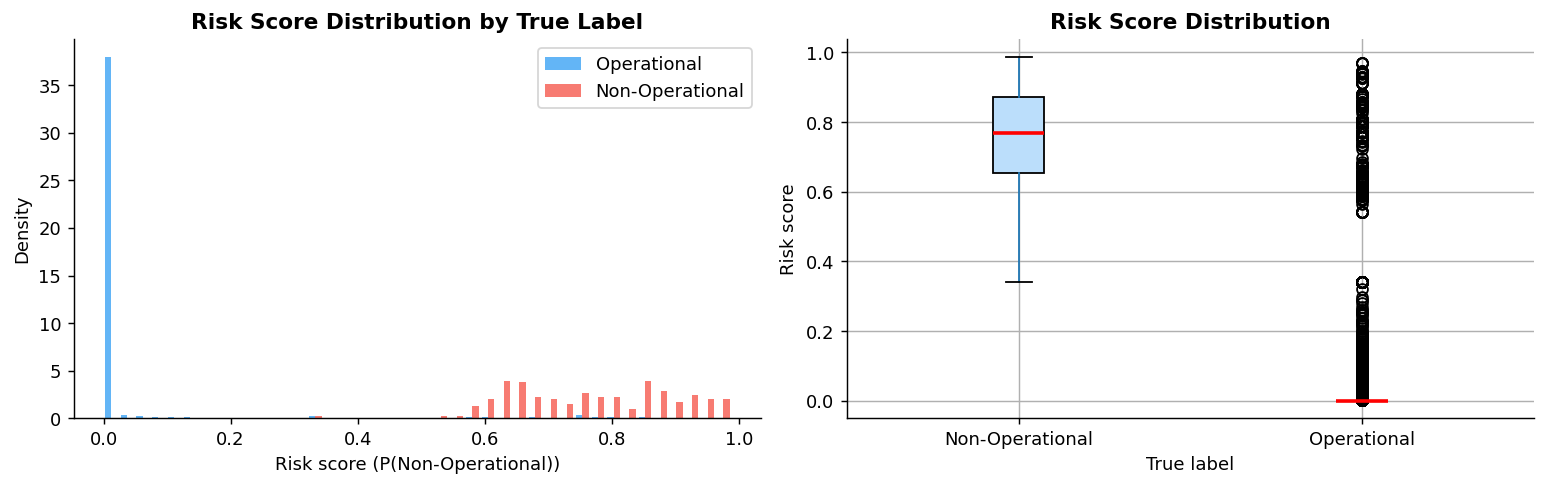

Mean risk score — Operational    : 0.028
Mean risk score — Non-Operational: 0.770


In [13]:
# Non-Op probability from the WITHOUT-country model is the operationally
# meaningful risk score — it reflects infrastructure characteristics, not geography.
risk_scores = rf_without_final.predict_proba(X_without)[:, 0]  # P(Non-Op)

df_risk = pd.DataFrame({
    "risk_score":  risk_scores,
    "true_label":  y.map({1: "Operational", 0: "Non-Operational"}),
    "predicted":   rf_without_final.predict(X_without),
}).sort_values("risk_score", ascending=False).reset_index(drop=True)

print("Top 20 highest-risk stations (RF WITHOUT country):")
print(df_risk.head(20).to_string())
print()

# Risk score distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    [df_risk.loc[df_risk["true_label"] == "Operational",    "risk_score"],
     df_risk.loc[df_risk["true_label"] == "Non-Operational","risk_score"]],
    bins=40, label=["Operational", "Non-Operational"],
    color=[COLOR_OP, COLOR_NOP], alpha=0.7, density=True
)
axes[0].set_xlabel("Risk score (P(Non-Operational))")
axes[0].set_ylabel("Density")
axes[0].set_title("Risk Score Distribution by True Label", fontweight="bold")
axes[0].legend()

# Score distribution as box
df_risk.boxplot(column="risk_score", by="true_label", ax=axes[1],
                patch_artist=True,
                boxprops=dict(facecolor="#BBDEFB"),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_title("Risk Score Distribution", fontweight="bold")
axes[1].set_xlabel("True label")
axes[1].set_ylabel("Risk score")
plt.suptitle("")

plt.tight_layout()
plt.savefig(FIG_DIR / "13_risk_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean risk score — Operational    : {df_risk.loc[df_risk['true_label']=='Operational',    'risk_score'].mean():.3f}")
print(f"Mean risk score — Non-Operational: {df_risk.loc[df_risk['true_label']=='Non-Operational','risk_score'].mean():.3f}")


## 13. Save Outputs

In [14]:
import pickle

# Save models
with open(ROOT / "reports" / "rf_with_country.pkl",    "wb") as f: pickle.dump(rf_with_final,    f)
with open(ROOT / "reports" / "rf_without_country.pkl", "wb") as f: pickle.dump(rf_without_final, f)
with open(ROOT / "reports" / "xgb_with_country.pkl",   "wb") as f: pickle.dump(xgb_with,         f)

# Save risk scores
df_risk.to_csv(PROC / "risk_scores_without_country.csv", index=False)

# Save CV results summary
cv_summary = {m["label"]: {
    "recall_mean":     m["recall_mean"],  "recall_std":     m["recall_std"],
    "f1_mean":         m["f1_mean"],      "f1_std":         m["f1_std"],
    "roc_auc_mean":    m["roc_auc_mean"], "roc_auc_std":    m["roc_auc_std"],
} for m in results}
import json
with open(ROOT / "reports" / "cv_results_summary.json", "w") as f:
    json.dump(cv_summary, f, indent=2)

print("Saved:")
print("  reports/rf_with_country.pkl")
print("  reports/rf_without_country.pkl")
print("  reports/xgb_with_country.pkl")
print("  data/processed/risk_scores_without_country.csv")
print("  reports/cv_results_summary.json")


Saved:
  reports/rf_with_country.pkl
  reports/rf_without_country.pkl
  reports/xgb_with_country.pkl
  data/processed/risk_scores_without_country.csv
  reports/cv_results_summary.json
